In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize

In [2]:
DATA_DIR = "/kaggle/input/datasets/lfreedom2750/mcvsld-split"
BATCH_SIZE = 64
IMAGE_SIZE = 224
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
NUM_WORKERS = 2
SAVE_DIR = Path("experiments/vgg16_scratch_notebook")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

In [4]:
train_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "val"),
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "test"),
    transform=eval_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

CLASS_NAMES = train_dataset.classes
CLASS_TO_IDX = train_dataset.class_to_idx
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Class to index:", CLASS_TO_IDX)
print("Num classes:", NUM_CLASSES)
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Classes: ['Chickenpox', 'Cowpox', 'HFMD', 'Healthy', 'Measles', 'Monkeypox']
Class to index: {'Chickenpox': 0, 'Cowpox': 1, 'HFMD': 2, 'Healthy': 3, 'Measles': 4, 'Monkeypox': 5}
Num classes: 6
Train samples: 7246
Val samples: 904
Test samples: 910


In [5]:
# Xem số lượng ảnh mỗi lớp
def count_per_class(dataset):
    counts = {}
    for _, label in dataset.samples:
        class_name = dataset.classes[label]
        counts[class_name] = counts.get(class_name, 0) + 1
    return counts

train_counts = count_per_class(train_dataset)
val_counts = count_per_class(val_dataset)
test_counts = count_per_class(test_dataset)

stats_df = pd.DataFrame({
    "train": pd.Series(train_counts),
    "val": pd.Series(val_counts),
    "test": pd.Series(test_counts),
}).fillna(0).astype(int)

stats_df

,train,val,test
Chickenpox,720,90,90
Cowpox,633,79,80
HFMD,1545,193,194
Healthy,1094,136,138
Measles,528,66,66
Monkeypox,2726,340,342


In [6]:
# =========================
# MODEL: VGG16 FROM SCRATCH
# =========================
model = models.vgg16(weights=None)
in_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(in_features, NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model.classifier)

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=6, bias=True)
)


In [7]:
# =========================
# HELPER FUNCTIONS
# =========================
def format_epoch_time(seconds: float) -> str:
    minutes = int(seconds // 60)
    secs = seconds % 60
    if minutes > 0:
        return f"{minutes}m {secs:.0f}s"
    return f"{secs:.0f}s"


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total if total > 0 else 0.0
    epoch_acc = correct / total if total > 0 else 0.0

    return epoch_loss, epoch_acc


def compute_specificity_multiclass(conf_matrix):
    specificities = []

    for i in range(conf_matrix.shape[0]):
        tp = conf_matrix[i, i]
        fn = conf_matrix[i, :].sum() - tp
        fp = conf_matrix[:, i].sum() - tp
        tn = conf_matrix.sum() - (tp + fn + fp)

        specificity_i = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specificities.append(specificity_i)

    return float(np.mean(specificities)), specificities


def evaluate_model(model, loader, criterion, device, num_classes):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            total_samples += batch_size

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    avg_loss = running_loss / total_samples if total_samples > 0 else 0.0

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    sensitivity = recall
    mcc = matthews_corrcoef(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)
    specificity_macro, specificity_per_class = compute_specificity_multiclass(cm)

    try:
        y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
        roc_auc = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")
    except ValueError:
        roc_auc = None

    metrics = {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "roc_auc_macro_ovr": roc_auc,
        "sensitivity_macro": sensitivity,
        "specificity_macro": specificity_macro,
        "specificity_per_class": specificity_per_class,
        "mcc": mcc,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

    return metrics


def print_metrics(metrics, class_names=None, split_name="Evaluation"):
    print(f"\n===== {split_name} Metrics =====")
    print(f"Loss         : {metrics['loss']:.4f}")
    print(f"Accuracy     : {metrics['accuracy']:.4f}")
    print(f"Precision    : {metrics['precision_macro']:.4f}")
    print(f"Recall       : {metrics['recall_macro']:.4f}")
    print(f"F1-score     : {metrics['f1_macro']:.4f}")

    if metrics["roc_auc_macro_ovr"] is not None:
        print(f"ROC-AUC      : {metrics['roc_auc_macro_ovr']:.4f}")
    else:
        print("ROC-AUC      : Không tính được")

    print(f"Sensitivity  : {metrics['sensitivity_macro']:.4f}")
    print(f"Specificity  : {metrics['specificity_macro']:.4f}")
    print(f"MCC          : {metrics['mcc']:.4f}")

    print("\nConfusion Matrix:")
    print(metrics["confusion_matrix"])

    if class_names is not None:
        print("\nClassification Report:")
        print(
            classification_report(
                metrics["y_true"],
                metrics["y_pred"],
                target_names=class_names,
                digits=4,
                zero_division=0
            )
        )


def plot_confusion_matrix(metrics, class_names, title="Confusion Matrix"):
    cm = metrics["confusion_matrix"]
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [8]:
# =========================
# TRAIN LOOP
# =========================
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "val_precision": [],
    "val_recall": [],
    "val_mcc": [],
}

best_val_acc = 0.0
best_model_path = SAVE_DIR / "best_vgg16_scratch_notebook.pth"

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )

    val_metrics = evaluate_model(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE,
        num_classes=NUM_CLASSES
    )

    epoch_time = time.time() - epoch_start_time
    epoch_time_str = format_epoch_time(epoch_time)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["val_f1"].append(val_metrics["f1_macro"])
    history["val_precision"].append(val_metrics["precision_macro"])
    history["val_recall"].append(val_metrics["recall_macro"])
    history["val_mcc"].append(val_metrics["mcc"])

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print(
        f"{epoch_time_str} - "
        f"accuracy: {train_acc:.4f} - "
        f"loss: {train_loss:.4f} - "
        f"val_accuracy: {val_metrics['accuracy']:.4f} - "
        f"val_loss: {val_metrics['loss']:.4f}"
    )
    print("Confusion Matrix (Validation):")
    print(val_metrics["confusion_matrix"])
    print("-" * 70)

    if val_metrics["accuracy"] > best_val_acc:
        best_val_acc = val_metrics["accuracy"]
        torch.save(model.state_dict(), best_model_path)

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")
print(f"Best model saved at: {best_model_path}")

Epoch 1/30
1m 50s - accuracy: 0.3649 - loss: 1.6149 - val_accuracy: 0.4204 - val_loss: 1.5701
Confusion Matrix (Validation):
[[  0   0   8   0   0  82]
 [  0   0   1   0   0  78]
 [  0   0  58   0   0 135]
 [  0   0  15   0   0 121]
 [  0   0  14   0   0  52]
 [  0   0  18   0   0 322]]
----------------------------------------------------------------------
Epoch 2/30
2m 3s - accuracy: 0.4586 - loss: 1.4540 - val_accuracy: 0.4712 - val_loss: 1.4219
Confusion Matrix (Validation):
[[  0   1  10   3   0  76]
 [  0  29  29   7   0  14]
 [  0   2 165   6   0  20]
 [  0   6  62  24   0  44]
 [  0   0  29   1   0  36]
 [  0  17 102  13   0 208]]
----------------------------------------------------------------------
Epoch 3/30
2m 2s - accuracy: 0.5242 - loss: 1.2850 - val_accuracy: 0.5476 - val_loss: 1.2177
Confusion Matrix (Validation):
[[ 24   1  11   6   3  45]
 [  1  35  13  17   0  13]
 [  0   4 138  40   1  10]
 [ 11   0  13  96   3  13]
 [ 24   1  18  11   6   6]
 [ 38  12  39  52   3 19

In [9]:
# Lịch sử train
history_df = pd.DataFrame(history)
history_df

,train_loss,train_acc,val_loss,val_acc,val_f1,val_precision,val_recall,val_mcc
0,1.614902,0.364891,1.570092,0.420354,0.157960,0.152728,0.207929,0.157445
1,1.453983,0.458598,1.421865,0.471239,0.301413,0.318325,0.335041,0.289728
2,1.285046,0.524151,1.217674,0.547566,0.457817,0.500019,0.466332,0.420067
3,1.172263,0.561275,1.095434,0.587389,0.452882,0.502439,0.480197,0.458806
4,1.029772,0.613304,0.898319,0.667035,0.624400,0.667744,0.603804,0.562706
5,0.877101,0.669473,0.769067,0.704646,0.617041,0.670726,0.615778,0.610435
6,0.712568,0.735440,0.596627,0.799779,0.763927,0.806164,0.740675,0.736341
7,0.578933,0.785675,0.633501,0.780973,0.744714,0.755705,0.754949,0.720936
8,0.454821,0.839360,0.503113,0.848451,0.813770,0.839354,0.806532,0.803542
9,0.368843,0.869445,0.413234,0.853982,0.836454,0.838088,0.838587,0.811493


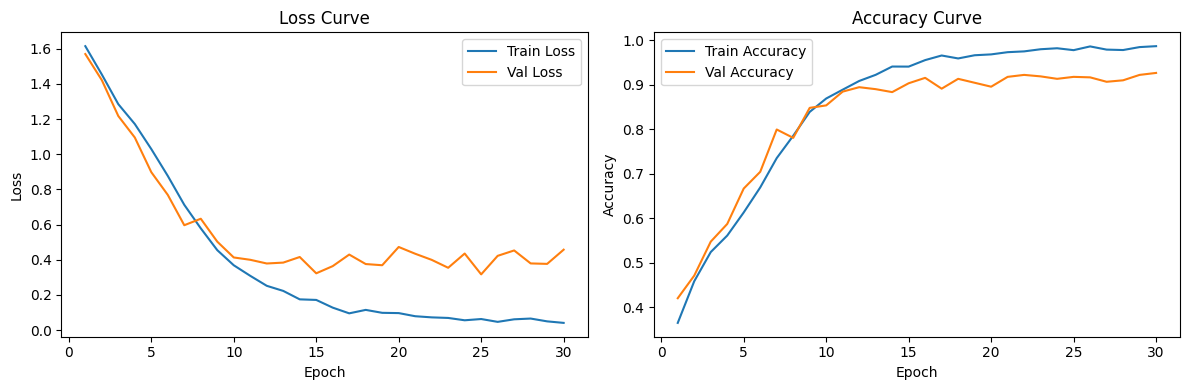

In [10]:
# Vẽ loss và accuracy
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# =========================
# LOAD BEST MODEL & TEST
# =========================
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_metrics = evaluate_model(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE,
    num_classes=NUM_CLASSES
)

print_metrics(test_metrics, class_names=CLASS_NAMES, split_name="Test")


===== Test Metrics =====
Loss         : 0.5098
Accuracy     : 0.9220
Precision    : 0.9265
Recall       : 0.8944
F1-score     : 0.9090
ROC-AUC      : 0.9851
Sensitivity  : 0.8944
Specificity  : 0.9823
MCC          : 0.8979

Confusion Matrix:
[[ 71   0   2   2   1  14]
 [  2  73   1   0   0   4]
 [  0   1 188   0   1   4]
 [  1   0   3 128   0   6]
 [  2   0   3   5  54   2]
 [ 10   0   6   1   0 325]]

Classification Report:
              precision    recall  f1-score   support

  Chickenpox     0.8256    0.7889    0.8068        90
      Cowpox     0.9865    0.9125    0.9481        80
        HFMD     0.9261    0.9691    0.9471       194
     Healthy     0.9412    0.9275    0.9343       138
     Measles     0.9643    0.8182    0.8852        66
   Monkeypox     0.9155    0.9503    0.9326       342

    accuracy                         0.9220       910
   macro avg     0.9265    0.8944    0.9090       910
weighted avg     0.9225    0.9220    0.9214       910



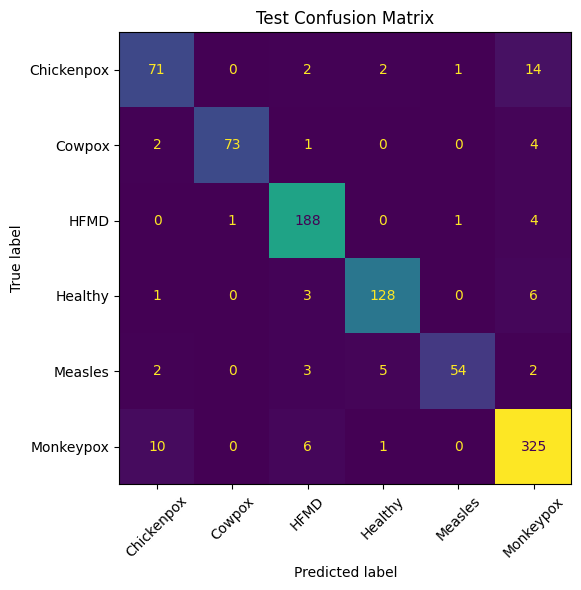

In [12]:
# Vẽ confusion matrix cho test
plot_confusion_matrix(test_metrics, CLASS_NAMES, title="Test Confusion Matrix")

In [13]:
# Lưu metrics test ra file CSV
test_summary = pd.DataFrame([{
    "loss": test_metrics["loss"],
    "accuracy": test_metrics["accuracy"],
    "precision_macro": test_metrics["precision_macro"],
    "recall_macro": test_metrics["recall_macro"],
    "f1_macro": test_metrics["f1_macro"],
    "roc_auc_macro_ovr": test_metrics["roc_auc_macro_ovr"],
    "sensitivity_macro": test_metrics["sensitivity_macro"],
    "specificity_macro": test_metrics["specificity_macro"],
    "mcc": test_metrics["mcc"],
}])

test_summary_path = SAVE_DIR / "test_metrics.csv"
test_summary.to_csv(test_summary_path, index=False)
print("Saved:", test_summary_path)
test_summary

Saved: experiments/vgg16_scratch_notebook/test_metrics.csv


,loss,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro_ovr,sensitivity_macro,specificity_macro,mcc
0,0.509787,0.921978,0.926522,0.894412,0.909016,0.985133,0.894412,0.982334,0.89795
